# RNN (Recurrent Neural Network) Hands-On On `Tesla` Dataset

> Import Dependencies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from warnings import filterwarnings
filterwarnings('ignore')


<h3> Load the dataset

In [ ]:
data = pd.read_csv('/content/Tesla.csv.csv')
data.head()

,Date,Open,High,Low,Close,Volume,Adj Close
0,6/29/2010,19.000000,25.00,17.540001,23.889999,18766300,23.889999
1,6/30/2010,25.790001,30.42,23.299999,23.830000,17187100,23.830000
2,7/1/2010,25.000000,25.92,20.270000,21.959999,8218800,21.959999
3,7/2/2010,23.000000,23.10,18.709999,19.200001,5139800,19.200001
4,7/6/2010,20.000000,20.00,15.830000,16.110001,6866900,16.110001


1. **Open:** The opening price of the stock on a particular trading day.

2. **High:** The highest price at which the stock traded during the `trading day`.

3. **Low:** The lowest price at which the stock traded during the `trading day`.

4. **Close:** The closing price of the stock for the day.

5. **Volume:** The total number of shares or contracts traded for the stock during the trading day. It reflects the level of activity or liquidity for the stock.

6. **Adj Close (Adjusted Close):** This is the closing price adjusted for corporate actions like `stock splits`, `dividends`, and `new stock offerings`.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1692 entries, 0 to 1691
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1692 non-null   object 
 1   Open       1692 non-null   float64
 2   High       1692 non-null   float64
 3   Low        1692 non-null   float64
 4   Close      1692 non-null   float64
 5   Volume     1692 non-null   int64  
 6   Adj Close  1692 non-null   float64
dtypes: float64(5), int64(1), object(1)
memory usage: 92.7+ KB


* In this dataset date is not in correct data-type so, we need to change the date data-type into datetime formate.

In [ ]:
data['Date'] = pd.to_datetime(data['Date'])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1692 entries, 0 to 1691
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1692 non-null   datetime64[ns]
 1   Open       1692 non-null   float64       
 2   High       1692 non-null   float64       
 3   Low        1692 non-null   float64       
 4   Close      1692 non-null   float64       
 5   Volume     1692 non-null   int64         
 6   Adj Close  1692 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 92.7 KB


In [ ]:
# Checking for the null values
data.isna().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Volume,0
Adj Close,0


* No Null values present in this dataset

In [ ]:
# Checking for the duplicate values
data.duplicated().sum()

np.int64(0)

* **No duplicate values**

In [ ]:
# Statistical analysis
data.describe()

,Date,Open,High,Low,Close,Volume,Adj Close
count,1692,1692.000000,1692.000000,1692.000000,1692.000000,1.692000e+03,1692.000000
mean,2013-11-06 02:53:37.021276416,132.441572,134.769698,129.996223,132.428658,4.270741e+06,132.428658
min,2010-06-29 00:00:00,16.139999,16.629999,14.980000,15.800000,1.185000e+05,15.800000
25%,2012-03-01 18:00:00,30.000000,30.650000,29.215000,29.884999,1.194350e+06,29.884999
50%,2013-11-05 12:00:00,156.334999,162.370002,153.150002,158.160004,3.180700e+06,158.160004
75%,2015-07-14 06:00:00,220.557495,224.099999,217.119999,220.022503,5.662100e+06,220.022503
max,2017-03-17 00:00:00,287.670013,291.420013,280.399994,286.040009,3.716390e+07,286.040009
std,NaN,94.309923,95.694914,92.855227,94.313187,4.295971e+06,94.313187


### Plot the `open price` distribution

In [ ]:
fig = px.histogram(data, x='Open', nbins=50, title='Distribution of Open Price')
fig.update_layout(xaxis_title='Open Price', yaxis_title='Frequency')
fig.update_traces(marker_color='darkblue')
fig.show()

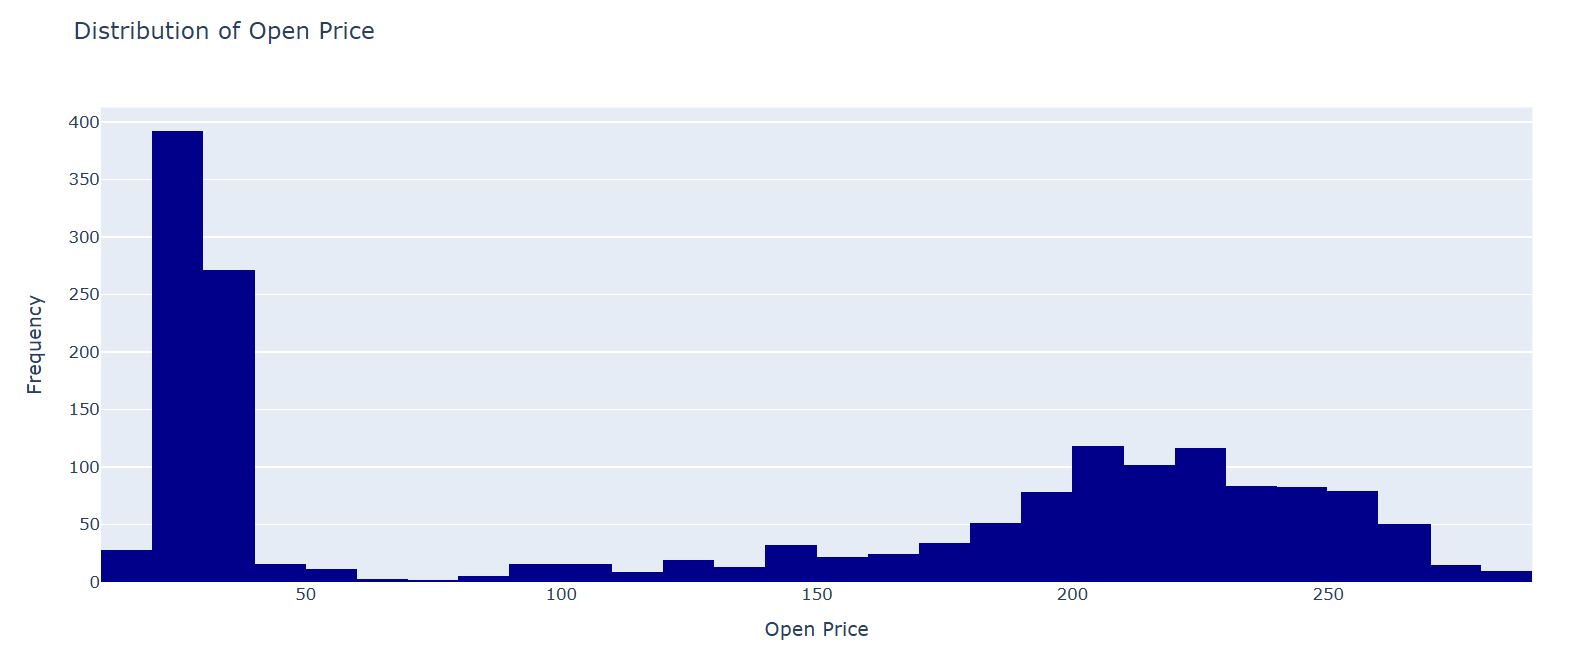

### Plot the `low` vs `high`

In [ ]:
fig = px.line(data, x='Date', y=['Low', 'High'], title='Low vs High Price', labels={'Date': 'Date', 'value': 'Price'})
fig.update_traces(line=dict(color='red'), selector=dict(name='Low'))
fig.update_traces(line=dict(color='blue'), selector=dict(name='High'))
fig.update_layout(xaxis_title='Date', yaxis_title='Price')
fig.show()

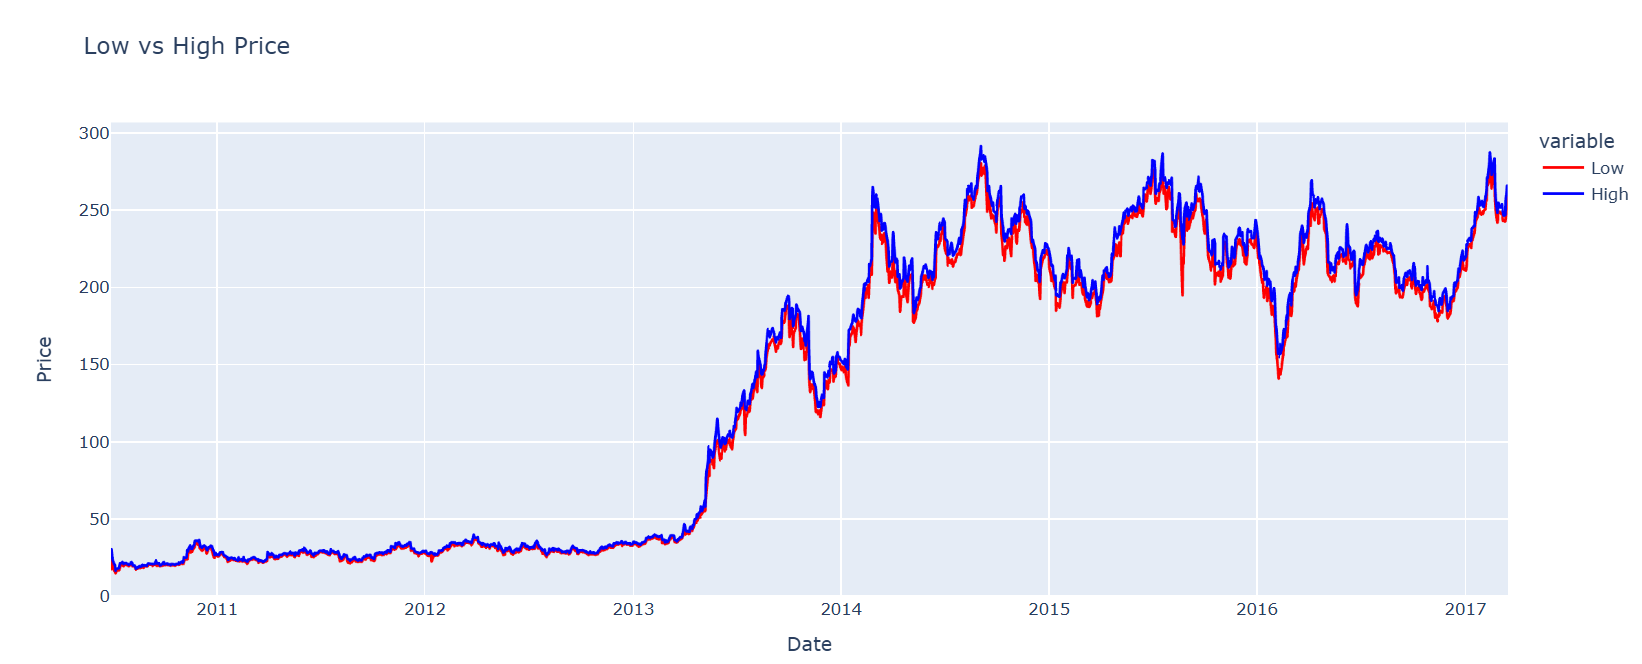

###  Splitting the `Tesla data` into `training` and `testing` sets

Train ratio: 70
Test ration: 30

In [ ]:
len_train_data = round(0.70 * len(data))
len_train_data

1184

In [ ]:
len_test_data = len(data) - len_train_data
len_test_data

508

In [ ]:
print("Data Length:", len(data))
print("Train data length:", len_train_data)
print("Validation data length:", len_test_data)

Data Length: 1692
Train data length: 1184
Validation data length: 508


> Training Dataset

In [ ]:
train_data = data[:len_train_data].iloc[:,:2]

In [ ]:
train_data

,Date,Open
0,2010-06-29,19.000000
1,2010-06-30,25.790001
2,2010-07-01,25.000000
3,2010-07-02,23.000000
4,2010-07-06,20.000000
...,...,...
1179,2015-03-06,199.210007
1180,2015-03-09,194.389999
1181,2015-03-10,188.460007
1182,2015-03-11,191.149994


> Testing dataset

In [ ]:
test_data = data[len_train_data:].iloc[:,:2]
test_data

,Date,Open
1184,2015-03-13,188.949997
1185,2015-03-16,192.000000
1186,2015-03-17,195.429993
1187,2015-03-18,194.960007
1188,2015-03-19,202.000000
...,...,...
1687,2017-03-13,244.820007
1688,2017-03-14,246.110001
1689,2017-03-15,257.000000
1690,2017-03-16,262.399994


In [ ]:
data_train = train_data.Open.values
data_train = data_train.reshape(-1,1)

In [ ]:
data_train

array([[ 19.      ],
       [ 25.790001],
       [ 25.      ],
       ...,
       [188.460007],
       [191.149994],
       [193.75    ]])

In [ ]:
data_test = test_data.Open.values
data_test = data_test.reshape(-1,1)

In [ ]:
data_test[:5]

array([[188.949997],
       [192.      ],
       [195.429993],
       [194.960007],
       [202.      ]])

# Normalization/Feature Scaling

* dataset values will be in between `0` and `1` after scaling

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [ ]:
data_train_scaled = scaler.fit_transform(data_train)
data_train_scaled

array([[0.01053291],
       [0.03553936],
       [0.03262991],
       ...,
       [0.634626  ],
       [0.64453278],
       [0.65410817]])

In [ ]:
data_test_scaled = scaler.fit_transform(data_test)
data_test_scaled[:5]

array([[0.33792299],
       [0.36002606],
       [0.38488289],
       [0.38147694],
       [0.43249509]])

In [ ]:
(data_train_scaled.min(),data_train_scaled.max())

(np.float64(0.0), np.float64(1.0))

visualize the `line chart` for `Tesla` Stock Open Price

#### Before Scaling the data

In [ ]:

fig = px.line(data_train, title='<b>Tesla Stock Open Price before scaling</b>')
fig.update_layout(xaxis_title="<b>Trading Days as 1,2,3,4,---</b>", yaxis_title='<b>Open Price</b>')
fig.update_traces(name='Train Data', line=dict(color='blue'))
fig.show()

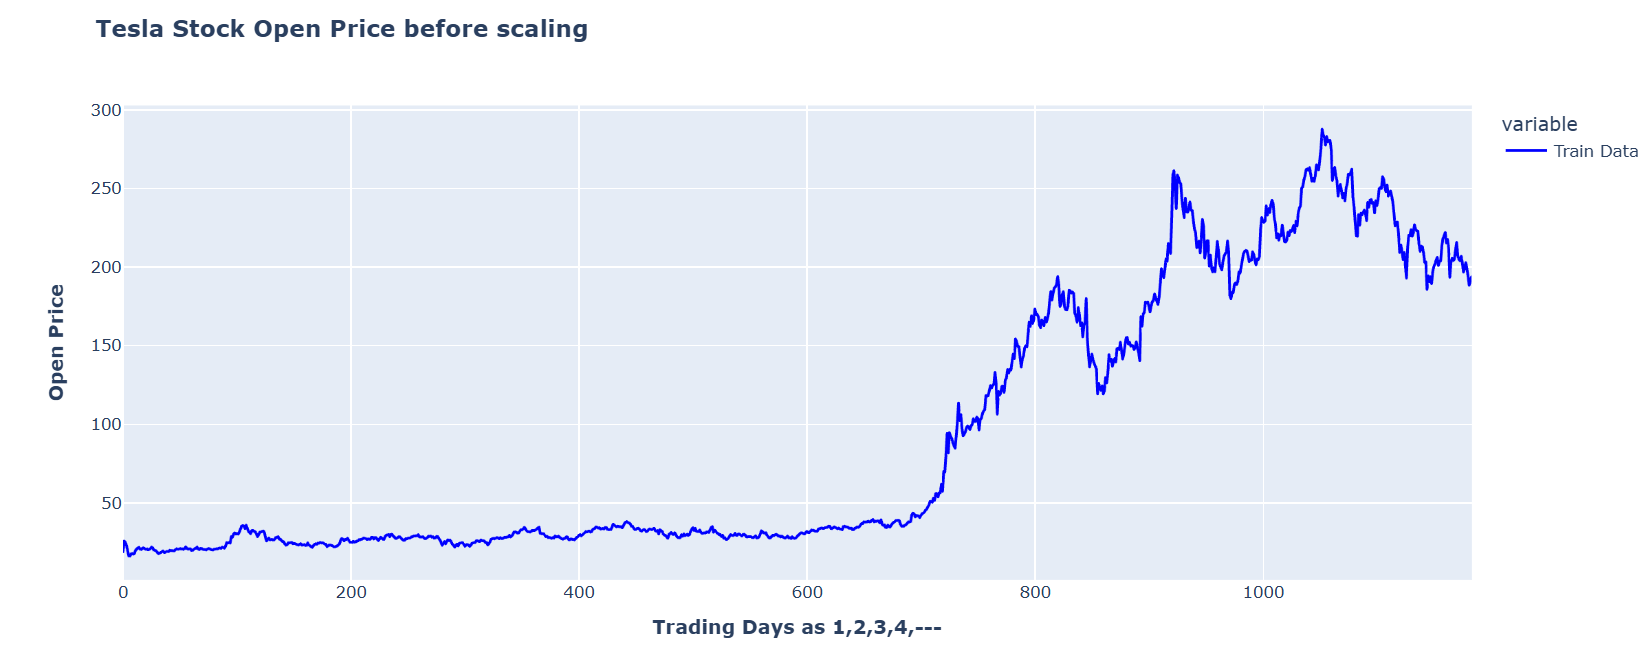

#### After Scaling

In [ ]:
fig = px.line(data_train_scaled, title='<b>Tesla Stock Open Price after scaling</b>')
fig.update_layout(xaxis_title='<b>Trading Days as 1,2,3,4,---</b>',yaxis_title='<b>Open Price</b>')
fig.update_traces(name = 'Train Data',line=dict(color='purple'))
fig.show()

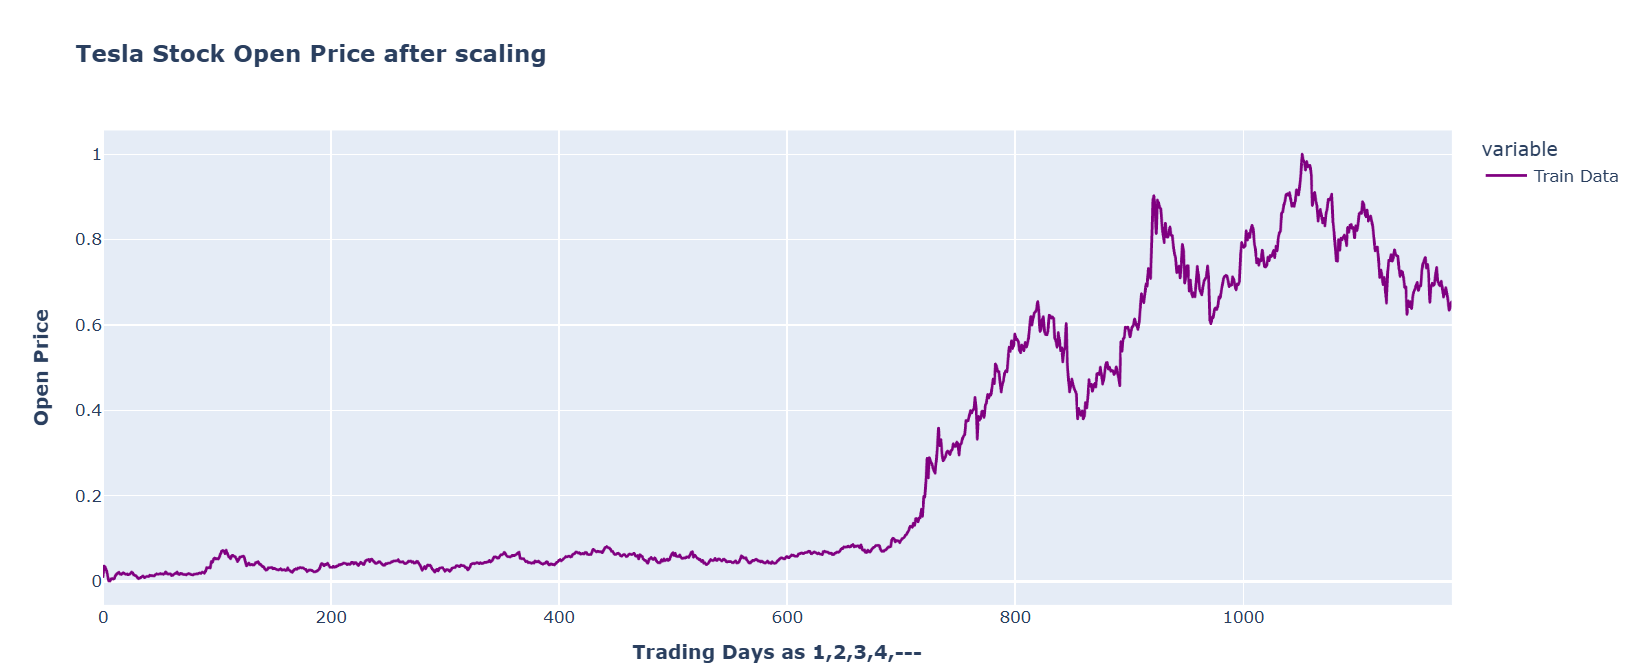

In [ ]:
X_train = []
Y_train = []
time_steps = 50
for i in range(time_steps,len_train_data):
    X_train.append(data_train_scaled[i-time_steps: i,0])
    Y_train.append(data_train_scaled[i,0])

In [ ]:
# Convert list into array
X_train, Y_train = np.array(X_train), np.array(Y_train)

In [ ]:
print("Shape of X_train before reshape:", X_train.shape)
print("Shape of y_train before reshape:", Y_train.shape)

Shape of X_train before reshape: (1134, 50)
Shape of y_train before reshape: (1134,)


In [ ]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
Y_train = np.reshape(Y_train, (Y_train.shape[0], 1))

In [ ]:
print("Shape of X_train before reshape:", X_train.shape)
print("Shape of y_train before reshape:", Y_train.shape)

Shape of X_train before reshape: (1134, 50, 1)
Shape of y_train before reshape: (1134, 1)


### 5. Build the `RNN` model

In [ ]:
from keras import Sequential
from keras.layers import SimpleRNN, Dense, Dropout

In [ ]:
rnn = Sequential()
rnn

<Sequential name=sequential_9, built=False>

In [ ]:

### Adding the first RNN layer and also the drop regularization
rnn.add(SimpleRNN(units=50, return_sequences=True, input_shape=(X_train.shape[1],1), activation='tanh'))
### Adding the second RNN layer and also the drop regularization
rnn.add(SimpleRNN(units=50,return_sequences=True,activation='tanh'))
rnn.add(Dropout(0.2))
### Adding the third RNN layer and also the drop regularization
rnn.add(SimpleRNN(units=50,return_sequences=True,activation='tanh'))

### Adding the 4th RNN layer and also the drop regularization
rnn.add(SimpleRNN(units=50,return_sequences=True,activation='tanh'))
rnn.add(Dropout(0.2))

## Adding Output Layer
rnn.add(Dense(units=1))

#### Compiling the RNN model
rnn.compile(optimizer = 'adam', loss="mean_squared_error", metrics=['accuracy'])

### Training the RNN
history = rnn.fit(X_train, Y_train, epochs=50, batch_size=32)


Epoch 1/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 7s 51ms/step - accuracy: 1.7138e-04 - loss: 0.1543
Epoch 2/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.0019 - loss: 0.0298
Epoch 3/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 9.1949e-04 - loss: 0.0202
Epoch 4/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 1.9994e-04 - loss: 0.0122
Epoch 5/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 7.0362e-05 - loss: 0.0101
Epoch 6/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.0018 - loss: 0.0096
Epoch 7/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 7.0362e-05 - loss: 0.0091
Epoch 8/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 7.1798e-05 - loss: 0.0078
Epoch 9/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.0011 - loss: 0.0079
Epoch 10/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 4.3277e-04 - loss: 0.0073
Epoch 11/50
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 1.4863e-04 - loss: 0.0071
Epoch 12/50
36/36 ━━━━━━━━━━━━━

In [ ]:
y_preds = rnn.predict(X_train)

36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step


In [ ]:
y_preds = y_preds[:,-1,:]
y_preds = scaler.inverse_transform(y_preds)

In [ ]:
y_preds.min(),y_preds.max()

(np.float32(21.065393), np.float32(248.0281))

In [ ]:
y_train = scaler.inverse_transform(Y_train)

In [ ]:
y_train.min(),y_train.max()

(np.float64(19.889999), np.float64(287.67001300000004))

In [ ]:
y_preds.min(),y_preds.max()

(np.float32(21.065393), np.float32(248.0281))

### Let us visualize the actual vs predicted for `training`

In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(y=y_train.flatten(), mode='lines', name='Actual Y_train'))
fig.add_trace(go.Scatter(y=y_preds.flatten(), mode='lines', name='Predicted Y_train'))

fig.update_layout(
    title='Actual vs Predicted for Training Data',
    xaxis_title='Trading Days',
    yaxis_title='Open Price'
)
fig.update_traces(line=dict(color='darkblue'), selector=dict(name='Actual Y_train'))
fig.update_traces(line=dict(color='darkorange'), selector=dict(name='Predicted Y_train'))
fig.show()

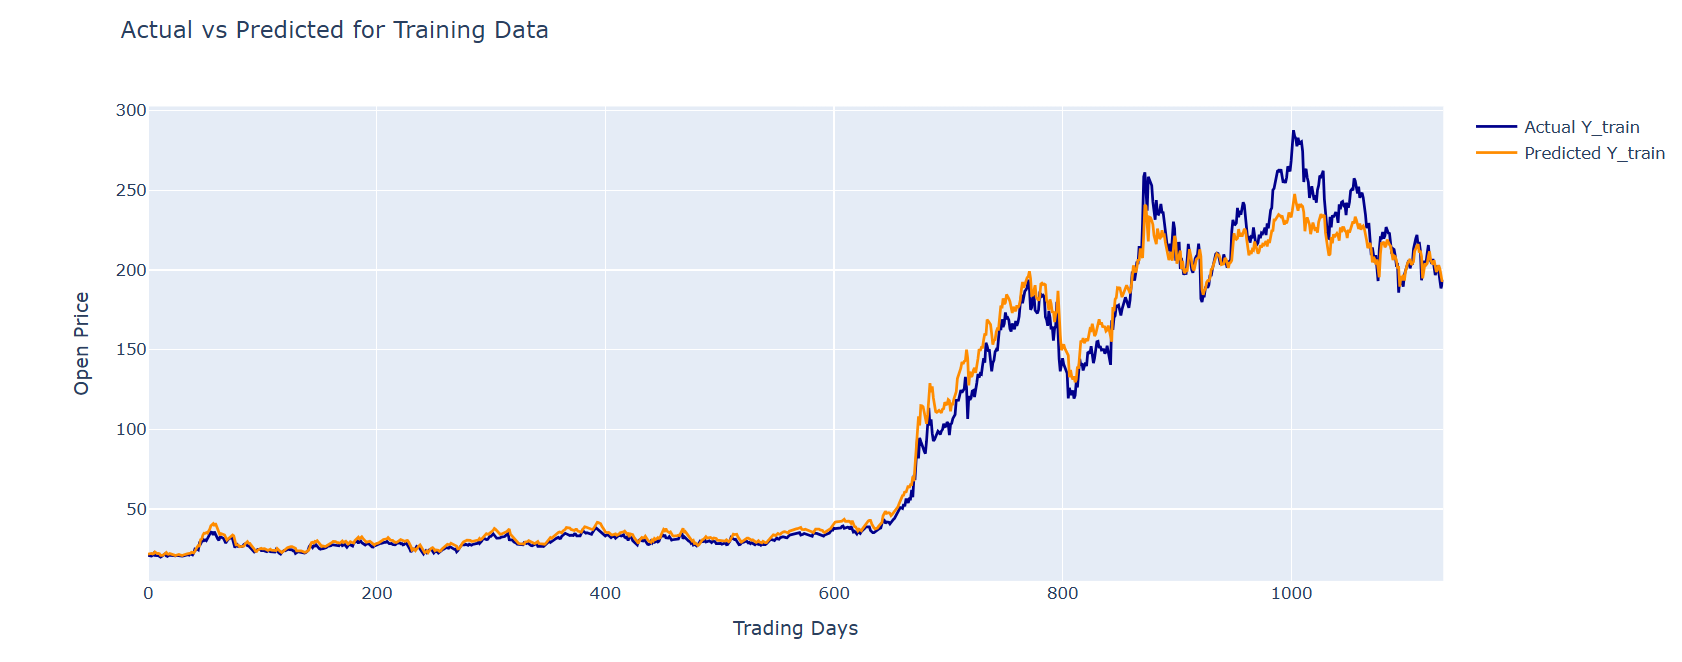

In [ ]:
X_test = []
Y_test = []
for i in range(time_steps,len_test_data):
    X_test.append(data_test_scaled[i-time_steps:i,0])
    Y_test.append(data_test_scaled[i,0])
# Converting to array
X_test, Y_test = np.array(X_test), np.array(Y_test)

In [ ]:
print("Shape of X_test before reshape :",X_test.shape)
print("Shape of y_test before reshape :",Y_test.shape)

Shape of X_test before reshape : (458, 50)
Shape of y_test before reshape : (458,)


In [ ]:
# reshape
X_test = np.reshape(X_test, (X_test.shape[0],X_test.shape[1],1))
Y_test = np.reshape(Y_test, (Y_test.shape[0],1))


In [ ]:
print("Shape of X_test before reshape :",X_test.shape)
print("Shape of y_test before reshape :",Y_test.shape)

Shape of X_test before reshape : (458, 50, 1)
Shape of y_test before reshape : (458, 1)


In [ ]:
y_test = scaler.inverse_transform(Y_test)

In [ ]:
y_test_preds = rnn.predict(X_test)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


In [ ]:
y_test_preds.min(), y_test_preds.max()

(np.float32(-0.12096533), np.float32(0.9119275))

In [ ]:
y_test_preds= y_test_preds[:, -1, :]
y_test_preds = scaler.inverse_transform(y_test_preds)

In [ ]:
y_test_preds.min(), y_test_preds.max()

(np.float32(127.7868), np.float32(260.50424))

In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(y=y_test.flatten(), mode='lines', name='Actual Y_test'))
fig.add_trace(go.Scatter(y=y_test_preds.flatten(),mode='lines', name = 'Predicted Y_test'))

fig.update_layout(
    title='Actual vs Predicted for Testing Data',
    xaxis_title='Trading Days',
    yaxis_title='Open Price',

)
fig.update_traces(line=dict(color='forestgreen'), selector= dict(name='Actual Y_test'))
fig.update_traces (line=dict(color='red'), selector= dict(name='Predicted Y_test')
)
fig.show()

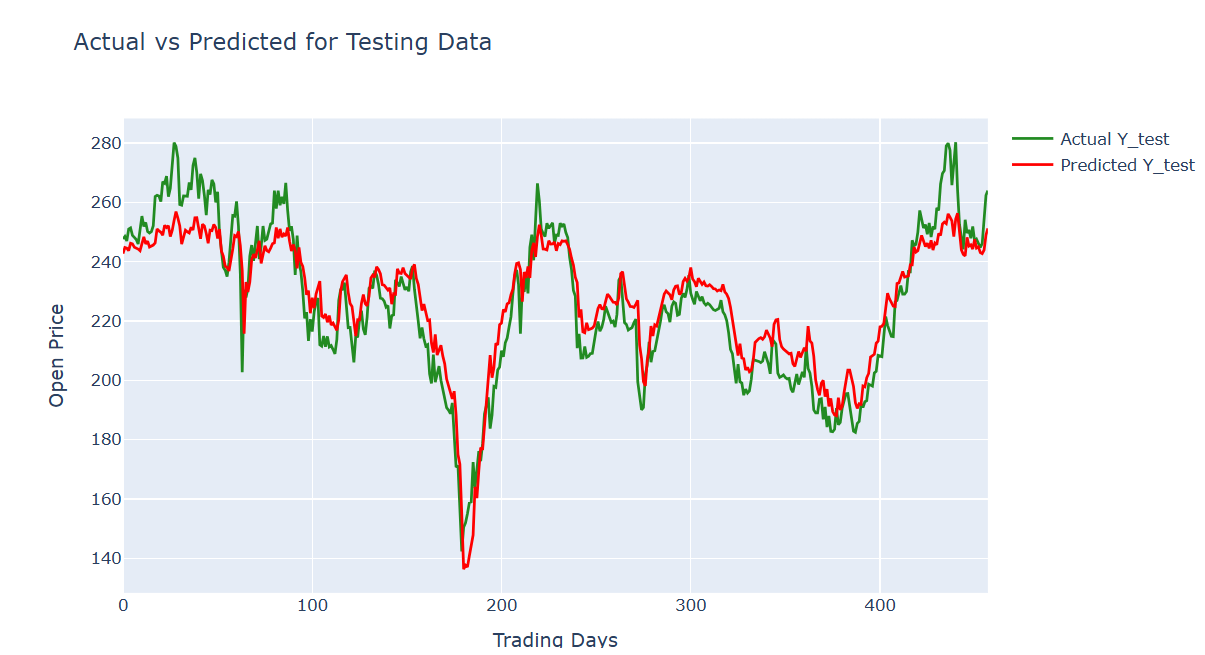

In [ ]:
time_step = 50

In [ ]:
train_data

,Date,Open
0,2010-06-29,19.000000
1,2010-06-30,25.790001
2,2010-07-01,25.000000
3,2010-07-02,23.000000
4,2010-07-06,20.000000
...,...,...
1179,2015-03-06,199.210007
1180,2015-03-09,194.389999
1181,2015-03-10,188.460007
1182,2015-03-11,191.149994


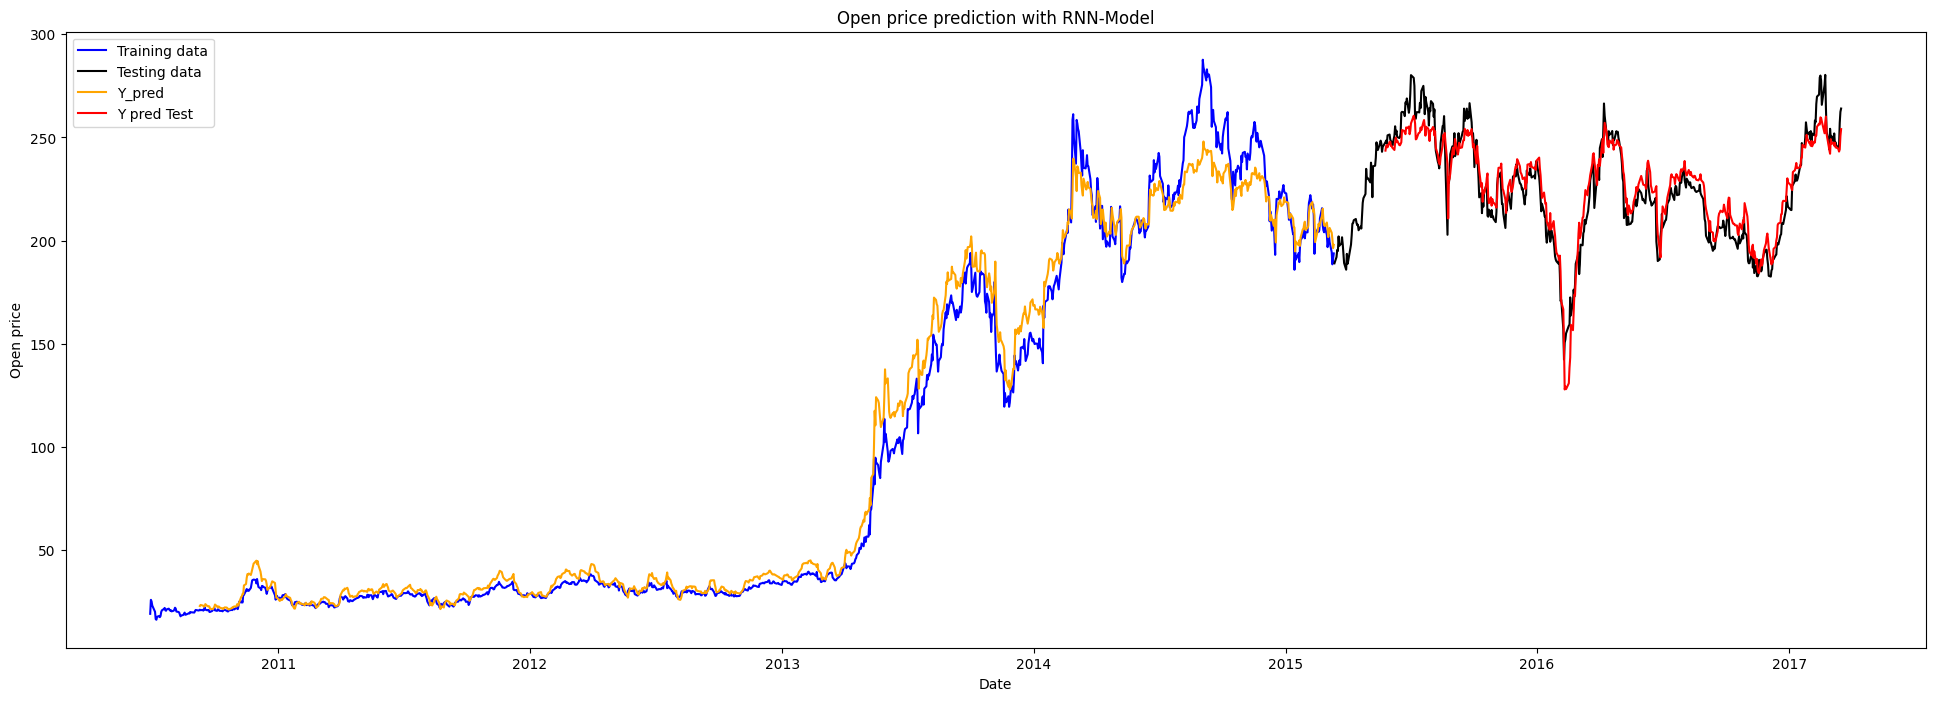

In [ ]:
plt.figure(figsize=(24,8))
plt.plot(train_data.Date, train_data.Open, label='Training data',color='blue')
plt.plot(test_data.Date, test_data.Open, label='Testing data',color='black')
plt.plot(train_data.Date.iloc[time_step:],y_preds,label='Y_pred',color='orange')
plt.plot(test_data.Date.iloc[time_step:],y_test_preds,label='Y pred Test',color='red')
plt.xlabel('Date')
plt.ylabel('Open price')
plt.title('Open price prediction with RNN-Model')
plt.legend()
plt.show()


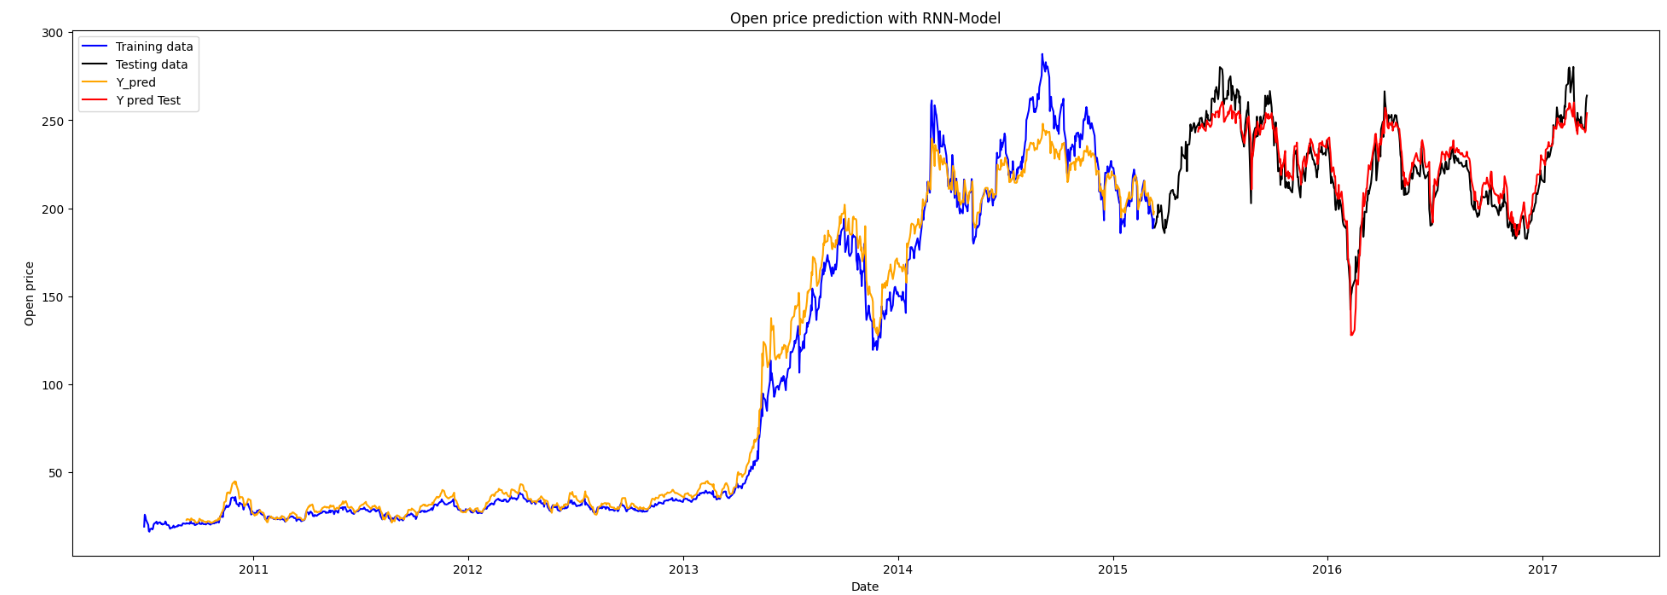